In [1]:
import zipfile, os
import pandas as pd

# ---- PATH TO YOUR ZIP FILE IN DRIVE ----
zip_path = "data_5L_new.zip"

# ---- UNZIP INTO A TEMP FOLDER ----
extract_dir = "/content/extracted_zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

csv_file = None
for file in os.listdir(extract_dir):
    if file.endswith(".csv"):
        csv_file = os.path.join(extract_dir, file)
        break

if csv_file is None:
    raise FileNotFoundError("No CSV file found inside the ZIP.")

# ---- LOAD INTO DATAFRAME ----
df = pd.read_csv(csv_file)

print("CSV loaded successfully!")
print(df.head())

CSV loaded successfully!
   policy_no policy_product cust_occupation  tier  tier_premium_amt  \
0     100000       Combined  skilled_worker     1            166.58   
1     100001       Combined  skilled_worker     2            342.37   
2     100002      Buildings  skilled_worker     2            325.97   
3     100003       Landlord         retired     1            160.16   
4     100004       Combined    professional     1            206.89   

   occupants_count  paying_guest_no business_use  unoccupied_days  \
0                4                0            N                0   
1                2                0            N                0   
2                1                0            N               30   
3                6                0            N                0   
4                2                0            N                0   

  unoccupied_reason  ... fire_safety_systems  security_systems  crime_rate  \
0               NaN  ...                   0           

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

def prepare_data(df):
    """Prepare data for modeling."""
    # Select relevant features for fraud detection
    feature_cols = [
        'tier', 'tier_premium_amt', 'occupants_count', 'paying_guest_no',
        'unoccupied_days', 'sum_insured', 'premium_with_tax',
        'risk_premium_with_credit_score', 'risk_premium_without_credit_score',
        'additional_coverage_amount', 'tier_limit_value', 'item_limit_value',
        'main_part_premium', 'accidental_damage_premium', 'outbuildings_premium',
        'APR_FLAG', 'previous_insurance_buildings', 'previous_insurance_cne',
        'property_eligibility', 'contents_claim_counts', 'building_claim_count',
        'flood_risk', 'storm_risk', 'other_natural_calamities_risk',
        'property_age', 'no_of_rooms', 'plumbing_elec_age',
        'smart_home', 'fire_safety_systems', 'security_systems',
        'crime_rate', 'no_of_claims_5yr', 'premium_payment_behaviour',
        'property_market_value', 'short_term_letting'
    ]

    # One-hot encode categorical variables
    categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                       'construction_material', 'roof_material', 'urban_rural', 'policy_product']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Get all feature columns (original + encoded)
    all_features = [col for col in df_encoded.columns if col in feature_cols or
                   any(cat in col for cat in categorical_cols)]

    X = df_encoded[all_features].values
    y = df['fraud_label'].values
    sum_insured = df['sum_insured'].values

    return X, y, sum_insured, all_features

# ==================== COST CALCULATION FUNCTIONS ====================

def calculate_costs(sum_insured, y_true, y_pred):
    """
    Calculate instance-dependent costs for fraud detection.

    Cost structure:
    - FN (Missing fraud): Lose 90% of sum_insured (fraud payout)
    - FP (False accusation): Fixed £100 administrative + customer relation cost
    - TN (Correct rejection): £0
    - TP (Caught fraud): £0
    """
    costs = np.zeros(len(y_true))

    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # False Negative (missed fraud)
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # False Positive (false accusation)
            costs[i] = 100
        # True Positive and True Negative have 0 cost

    return costs

def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive cost-sensitive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    total_cost = np.sum(costs)

    # Breakdown by error type
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    fn_cost = np.sum(costs[fn_mask])
    fp_cost = np.sum(costs[fp_mask])
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)

    # Traditional metrics
    tn = np.sum((y_true == 0) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    results = {
        'total_cost': total_cost,
        'fn_cost': fn_cost,
        'fp_cost': fp_cost,
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp,
        'tn': tn,
        'avg_cost_per_sample': total_cost / len(y_true)
    }

    # Calculate rates
    if tp + fn_count > 0:
        results['recall'] = tp / (tp + fn_count)
    else:
        results['recall'] = 0

    if tp + fp_count > 0:
        results['precision'] = tp / (tp + fp_count)
    else:
        results['precision'] = 0

    return results

# ==================== RULE-BASED SYSTEM ====================

def apply_fraud_rules(df):
    """
    UK Industry-standard fraud detection rules.
    Returns flagged indices based on rule violations.
    """
    flags = pd.Series(False, index=df.index)

    # Calculate derived metrics
    claim_ratio = df['sum_insured'] / (df['premium_with_tax'] + 1)
    coverage_ratio = df['sum_insured'] / (df['property_market_value'] + 1)

    # RULE 1: High claim ratio + early policyholder (no previous insurance)
    flags |= (claim_ratio > 1500) & (df['previous_insurance_buildings'] == 0) & (df['no_of_claims_5yr'] > 0)

    # RULE 2: Accidental damage + unoccupied + early claim
    flags |= (df['accidental_damage_premium'] > 0) & (df['unoccupied_days'] >= 30) & (df['no_of_claims_5yr'] > 0)

    # RULE 3: High claim frequency
    flags |= (df['no_of_claims_5yr'] >= 3)

    # RULE 4: Unoccupied + business use + claims
    flags |= (df['unoccupied_days'] >= 30) & (df['business_use'] == 'Y') & (df['no_of_claims_5yr'] > 0)

    # RULE 5: Coverage inflation
    flags |= (coverage_ratio > 0.8) & (df['no_of_claims_5yr'] > 0)

    # RULE 6: High additional coverage
    flags |= (df['additional_coverage_amount'] >= 15000) & (df['no_of_claims_5yr'] > 0)

    # RULE 7: Payment issues + claims
    flags |= (df['premium_payment_behaviour'] < 70) & (df['no_of_claims_5yr'] >= 2)

    # RULE 8: Short-term letting + claims
    flags |= (df['short_term_letting'] == 1) & (df['no_of_claims_5yr'] >= 2)

    return flags


# ==================== HELPER FUNCTIONS ====================

def prepare_features(df, categorical_cols=None):
    """Prepare features with one-hot encoding."""
    if categorical_cols is None:
        categorical_cols = ['cust_occupation', 'owner_details', 'property_type',
                          'construction_material', 'roof_material', 'urban_rural', 'policy_product', 'business_use']

    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # Exclude target and metadata columns
    exclude_cols = ['fraud_label', 'fraud_probability', 'policy_no', 'unoccupied_reason']
    feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

    return df_encoded[feature_cols]


def calculate_costs(sum_insured, y_true, y_pred):
    """Calculate instance-dependent costs."""
    costs = np.zeros(len(y_true))
    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 0:  # FN
            costs[i] = sum_insured[i] * 0.90
        elif y_true[i] == 0 and y_pred[i] == 1:  # FP
            costs[i] = 100
    return costs


def evaluate_cost_sensitive(y_true, y_pred, sum_insured):
    """Comprehensive evaluation."""
    costs = calculate_costs(sum_insured, y_true, y_pred)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn_count = np.sum(fn_mask)
    fp_count = np.sum(fp_mask)

    recall = tp / (tp + fn_count) if (tp + fn_count) > 0 else 0
    precision = tp / (tp + fp_count) if (tp + fp_count) > 0 else 0

    return {
        'total_cost': np.sum(costs),
        'fn_cost': np.sum(costs[fn_mask]),
        'fp_cost': np.sum(costs[fp_mask]),
        'fn_count': fn_count,
        'fp_count': fp_count,
        'tp': tp, 'tn': tn,
        'recall': recall,
        'precision': precision
    }


def find_optimal_threshold(model, X, y, sum_insured):
    """Find cost-minimizing threshold."""
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.1, 0.9, 50)
    best_cost = float('inf')
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cost = np.sum(calculate_costs(sum_insured, y, y_pred))
        if cost < best_cost:
            best_cost = cost
            best_threshold = threshold

    return best_threshold


# ==================== ACTIVE LEARNING PIPELINE ====================

class RealWorldActiveLearning:
    """
    Active Learning as per transcript workflow:
    1. Rule-based filtering on initial customers
    2. Train ML model on investigated (flagged) cases
    3. Monthly/Quarterly: Test on new customers, query uncertain cases
    4. Retrain with expanded labeled set
    5. Track performance improvement over time
    """

    def __init__(self, model_type='xgboost'):
        self.model_type = model_type
        self.model = None
        self.scaler = StandardScaler()
        self.threshold = 0.5
        self.labeled_data = {'X': [], 'y': [], 'sum_insured': []}
        self.performance_history = []
        self.feature_names = None

    def initialize_model(self):
        """Initialize ML model."""
        if self.model_type == 'xgboost':
            self.model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                scale_pos_weight=5,  # Handle imbalance
                random_state=42,
                eval_metric='logloss'
            )
        else:
            self.model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                class_weight='balanced',
                random_state=42
            )

    def rule_based_filtering(self, df_universe, n_initial=10000):
        """
        Step 1: Take initial customers from universe, apply rules, flag suspicious.
        Returns: flagged indices from universe
        """
        print("="*80)
        print("STEP 1: RULE-BASED FILTERING")
        print("="*80)

        # Sample initial customers
        initial_customers = df_universe.sample(n=min(n_initial, len(df_universe)), random_state=42)

        # Apply fraud rules
        suspicious_flags = apply_fraud_rules(initial_customers)
        flagged_indices = initial_customers[suspicious_flags].index

        print(f"Initial customers: {len(initial_customers)}")
        print(f"Flagged as suspicious: {len(flagged_indices)} ({len(flagged_indices)/len(initial_customers)*100:.1f}%)")

        return flagged_indices, initial_customers.index

    def investigate_and_train(self, df_universe, flagged_indices):
        """
        Step 2: Investigate flagged cases (get true labels from universe).
        Train initial ML model on investigated cases.
        """
        print("\n" + "="*80)
        print("STEP 2: INVESTIGATION & INITIAL MODEL TRAINING")
        print("="*80)

        # Get investigated cases with true labels
        investigated = df_universe.loc[flagged_indices]

        # Prepare features
        X_features = prepare_features(investigated.copy())
        self.feature_names = X_features.columns.tolist()
        X = X_features.values
        y = investigated['fraud_label'].values
        sum_insured = investigated['sum_insured'].values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        # Store labeled data
        self.labeled_data['X'] = X_scaled.copy()
        self.labeled_data['y'] = y.copy()
        self.labeled_data['sum_insured'] = sum_insured.copy()

        # Train model
        self.initialize_model()
        self.model.fit(X_scaled, y)

        # Find optimal threshold
        self.threshold = find_optimal_threshold(self.model, X_scaled, y, sum_insured)

        print(f"Investigated cases: {len(flagged_indices)}")
        print(f"Fraud cases found: {y.sum()} ({y.mean()*100:.1f}%)")
        print(f"Initial model trained with {len(X)} samples")
        print(f"Optimal threshold: {self.threshold:.3f}")

        return X_scaled, y, sum_insured

    def test_model(self, df_test):
        """
        Step 3: Test model on new customers.
        Returns predictions and evaluation metrics.
        """
        # Prepare test features
        X_features = prepare_features(df_test.copy())
        # Align features with training
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_test = X_features.values
        X_test_scaled = self.scaler.transform(X_test)
        y_test = df_test['fraud_label'].values
        sum_test = df_test['sum_insured'].values

        # Predict
        y_proba = self.model.predict_proba(X_test_scaled)[:, 1]
        y_pred = (y_proba >= self.threshold).astype(int)

        # Evaluate
        results = evaluate_cost_sensitive(y_test, y_pred, sum_test)
        results['y_proba'] = y_proba

        return results

    def query_uncertain_cases(self, df_new, uncertainty_range=(0.2, 0.8), top_n=None):
        """
        FIXED: Query uncertain cases + high-confidence positives for balanced learning.
        """
        # Prepare features
        X_features = prepare_features(df_new.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X = X_features.values
        X_scaled = self.scaler.transform(X)

        # Get prediction probabilities
        y_proba = self.model.predict_proba(X_scaled)[:, 1]

        # Strategy 1: Uncertain cases (0.2-0.8)
        uncertain_mask = (y_proba >= uncertainty_range[0]) & (y_proba <= uncertainty_range[1])

        # Strategy 2: High-confidence frauds (>0.8) - verify these too
        high_conf_fraud = y_proba > 0.8

        # Strategy 3: Some low-confidence legitimate (<0.2) for balance
        low_conf_legit = y_proba < 0.2

        # Combine: 70% uncertain, 20% high-conf fraud, 10% low-conf legit
        uncertain_idx = df_new[uncertain_mask].index.tolist()
        high_fraud_idx = df_new[high_conf_fraud].index.tolist()
        low_legit_idx = df_new[low_conf_legit].index.tolist()

        if top_n:
            n_uncertain = int(top_n * 0.7)
            n_high = int(top_n * 0.2)
            n_low = top_n - n_uncertain - n_high

            # Sample with cost-weighting
            selected = []

            if len(uncertain_idx) > 0:
                n_sample = min(n_uncertain, len(uncertain_idx))
                weights = df_new.loc[uncertain_idx, 'sum_insured'].values
                weights = weights / weights.sum()
                selected.extend(np.random.choice(uncertain_idx, n_sample, replace=False, p=weights))

            if len(high_fraud_idx) > 0:
                n_sample = min(n_high, len(high_fraud_idx))
                selected.extend(np.random.choice(high_fraud_idx, n_sample, replace=False))

            if len(low_legit_idx) > 0:
                n_sample = min(n_low, len(low_legit_idx))
                selected.extend(np.random.choice(low_legit_idx, n_sample, replace=False))

            uncertain_indices = selected
        else:
            uncertain_indices = uncertain_idx + high_fraud_idx[:20] + low_legit_idx[:10]

        return uncertain_indices

    def retrain_with_new_labels(self, df_universe, new_labeled_indices):
        """
        FIXED: Add new labels but maintain stable threshold.
        """
        # Get new labeled data
        new_data = df_universe.loc[new_labeled_indices]
        X_features = prepare_features(new_data.copy())
        for col in self.feature_names:
            if col not in X_features.columns:
                X_features[col] = 0
        X_features = X_features[self.feature_names]

        X_new = X_features.values
        X_new_scaled = self.scaler.transform(X_new)
        y_new = new_data['fraud_label'].values
        sum_new = new_data['sum_insured'].values

        # Append to labeled data
        self.labeled_data['X'] = np.vstack([self.labeled_data['X'], X_new_scaled])
        self.labeled_data['y'] = np.concatenate([self.labeled_data['y'], y_new])
        self.labeled_data['sum_insured'] = np.concatenate([self.labeled_data['sum_insured'], sum_new])

        # Retrain model
        self.model.fit(self.labeled_data['X'], self.labeled_data['y'])

        # FIXED: Only update threshold if significant improvement (>5% cost reduction)
        old_threshold = self.threshold
        new_threshold = find_optimal_threshold(
            self.model,
            self.labeled_data['X'],
            self.labeled_data['y'],
            self.labeled_data['sum_insured']
        )

        # Test both thresholds on training data
        y_proba = self.model.predict_proba(self.labeled_data['X'])[:, 1]

        cost_old = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= old_threshold).astype(int)
        ))

        cost_new = np.sum(calculate_costs(
            self.labeled_data['sum_insured'],
            self.labeled_data['y'],
            (y_proba >= new_threshold).astype(int)
        ))

        # Only update if >5% improvement
        if cost_new < cost_old * 0.95:
            self.threshold = new_threshold

        return len(self.labeled_data['y'])


# ==================== COMPLETE WORKFLOW ====================

def run_active_learning_workflow(df_universe, n_test=5000, n_months=6, monthly_customers=500):
    """
    Complete Active Learning workflow:

    1. Rule-based filtering on 10K initial customers
    2. Train ML model on flagged cases (~2K investigated)
    3. Test on 5K new customers (baseline performance)
    4. Monthly loop (6 months):
       - New customers arrive (500/month)
       - Test model, query uncertain cases
       - Investigate and add to training
       - Retrain model
    5. Final test on 5K customers (show improvement)
    """

    print("\n" + "="*100)
    print(" "*30 + "ACTIVE LEARNING WORKFLOW")
    print("="*100)

    al = RealWorldActiveLearning(model_type='xgboost')

    # Track used indices
    used_indices = set()

    # ==================== STEP 1 & 2: RULE-BASED + INITIAL TRAINING ====================
    flagged_idx, initial_idx = al.rule_based_filtering(df_universe, n_initial=10000)
    used_indices.update(initial_idx)

    X_train, y_train, sum_train = al.investigate_and_train(df_universe, flagged_idx)

    # ==================== STEP 3: INITIAL TEST (BASELINE) ====================
    print("\n" + "="*80)
    print("STEP 3: BASELINE TEST (Before Active Learning)")
    print("="*80)

    available_test = df_universe.drop(index=used_indices)
    test_baseline = available_test.sample(n=min(n_test, len(available_test)), random_state=42)
    used_indices.update(test_baseline.index)

    results_baseline = al.test_model(test_baseline)

    print(f"Test samples: {len(test_baseline)}")
    print(f"Total Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"Recall: {results_baseline['recall']*100:.1f}%")
    print(f"Precision: {results_baseline['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': 0,
        'month': 'Baseline',
        'labeled_count': len(al.labeled_data['y']),
        **results_baseline
    })

    # ==================== STEP 4: MONTHLY ACTIVE LEARNING LOOP ====================
    print("\n" + "="*80)
    print("STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS")
    print("="*80)

    # Fixed test set for consistent monthly evaluation
    available_monthly_test = df_universe.drop(index=used_indices)
    monthly_test_set = available_monthly_test.sample(n=min(1000, len(available_monthly_test)), random_state=999)
    used_indices.update(monthly_test_set.index)

    for month in range(1, n_months + 1):
        print(f"\n--- Month {month} ---")

        # New customers arrive
        available = df_universe.drop(index=used_indices)
        if len(available) < monthly_customers:
            print(f"Insufficient data remaining. Stopping at month {month-1}.")
            break

        new_customers = available.sample(n=monthly_customers, random_state=42+month)
        used_indices.update(new_customers.index)

        # Query uncertain cases (70% uncertain, 20% high-conf, 10% low-conf)
        uncertain_idx = al.query_uncertain_cases(new_customers, uncertainty_range=(0.2, 0.8), top_n=100)

        print(f"New customers: {len(new_customers)}")
        print(f"Cases queried for investigation: {len(uncertain_idx)}")

        # Investigate and retrain
        if len(uncertain_idx) > 0:
            new_labeled_count = al.retrain_with_new_labels(df_universe, uncertain_idx)
            print(f"Total labeled data: {new_labeled_count}")
            print(f"Threshold: {al.threshold:.3f}")

        # FIXED: Test on consistent held-out test set (not remaining customers)
        results_month = al.test_model(monthly_test_set)
        print(f"Monthly test cost (fixed test set): £{results_month['total_cost']:,.0f}")

        al.performance_history.append({
            'iteration': month,
            'month': f'Month {month}',
            'labeled_count': len(al.labeled_data['y']),
            **results_month
        })

    # ==================== STEP 5: FINAL TEST (SHOW IMPROVEMENT) ====================
    print("\n" + "="*80)
    print("STEP 5: FINAL TEST (After Active Learning)")
    print("="*80)

    available_final = df_universe.drop(index=used_indices)
    test_final = available_final.sample(n=min(n_test, len(available_final)), random_state=99)

    results_final = al.test_model(test_final)

    print(f"Test samples: {len(test_final)}")
    print(f"Total Cost: £{results_final['total_cost']:,.0f}")
    print(f"Recall: {results_final['recall']*100:.1f}%")
    print(f"Precision: {results_final['precision']*100:.1f}%")

    al.performance_history.append({
        'iteration': n_months + 1,
        'month': 'Final Test',
        'labeled_count': len(al.labeled_data['y']),
        **results_final
    })

    # ==================== RESULTS SUMMARY ====================
    print("\n" + "="*100)
    print("PERFORMANCE IMPROVEMENT SUMMARY")
    print("="*100)

    history_df = pd.DataFrame(al.performance_history)

    print(f"\nBaseline (Initial Model):")
    print(f"  Cost: £{results_baseline['total_cost']:,.0f}")
    print(f"  Recall: {results_baseline['recall']*100:.1f}%")

    print(f"\nFinal (After {n_months} months AL):")
    print(f"  Cost: £{results_final['total_cost']:,.0f}")
    print(f"  Recall: {results_final['recall']*100:.1f}%")

    cost_improvement = (results_baseline['total_cost'] - results_final['total_cost']) / results_baseline['total_cost'] * 100
    recall_improvement = (results_final['recall'] - results_baseline['recall']) * 100

    print(f"\nImprovement:")
    print(f"  Cost Reduction: {cost_improvement:+.1f}%")
    print(f"  Recall Gain: {recall_improvement:+.1f} percentage points")
    print(f"  Total Labeled Data: {len(al.labeled_data['y'])} samples")

    # ==================== VISUALIZATION ====================
    visualize_results(history_df, results_baseline, results_final, n_months)

    return al, history_df


def visualize_results(history_df, baseline, final, n_months):
    """Create comprehensive visualization."""

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Cost over time
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(history_df['iteration'], history_df['total_cost']/1000,
             marker='o', linewidth=2, markersize=8, color='#e74c3c')
    ax1.axhline(y=baseline['total_cost']/1000, color='gray', linestyle='--', label='Baseline', alpha=0.7)
    ax1.set_xlabel('Iteration', fontsize=11)
    ax1.set_ylabel('Total Cost (£K)', fontsize=11)
    ax1.set_title('Cost Reduction Over Time', fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # 2. Recall improvement
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(history_df['iteration'], history_df['recall']*100,
             marker='s', linewidth=2, markersize=8, color='#2ecc71')
    ax2.set_xlabel('Iteration', fontsize=11)
    ax2.set_ylabel('Recall (%)', fontsize=11)
    ax2.set_title('Recall Over Time', fontsize=13, fontweight='bold')
    ax2.grid(alpha=0.3)

    # 3. Labeled data growth
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.bar(history_df['iteration'], history_df['labeled_count'], color='#3498db', alpha=0.7)
    ax3.set_xlabel('Iteration', fontsize=11)
    ax3.set_ylabel('Labeled Samples', fontsize=11)
    ax3.set_title('Training Data Growth', fontsize=13, fontweight='bold')
    ax3.grid(alpha=0.3, axis='y')

    # 4. FN vs FP cost
    ax4 = fig.add_subplot(gs[1, 1])
    x = np.arange(len(history_df))
    width = 0.35
    ax4.bar(x - width/2, history_df['fn_cost']/1000, width, label='FN Cost', color='#e74c3c')
    ax4.bar(x + width/2, history_df['fp_cost']/1000, width, label='FP Cost', color='#f39c12')
    ax4.set_xlabel('Iteration', fontsize=11)
    ax4.set_ylabel('Cost (£K)', fontsize=11)
    ax4.set_title('Cost Breakdown', fontsize=13, fontweight='bold')
    ax4.legend()
    ax4.grid(alpha=0.3, axis='y')

    # 5. Precision vs Recall
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.scatter(history_df['recall']*100, history_df['precision']*100,
               s=200, c=history_df['total_cost'], cmap='RdYlGn_r',
               edgecolors='black', linewidth=1.5)
    ax5.set_xlabel('Recall (%)', fontsize=11)
    ax5.set_ylabel('Precision (%)', fontsize=11)
    ax5.set_title('Precision-Recall Trade-off', fontsize=13, fontweight='bold')
    ax5.grid(alpha=0.3)
    cbar = plt.colorbar(ax5.collections[0], ax=ax5)
    cbar.set_label('Cost (£)', fontsize=9)

    # 6. Summary metrics table
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('off')

    summary_data = [
        ['Metric', 'Baseline', f'After {n_months}M', 'Change'],
        ['Total Cost (£)', f'{baseline["total_cost"]:,.0f}', f'{final["total_cost"]:,.0f}',
         f'{(baseline["total_cost"]-final["total_cost"])/baseline["total_cost"]*100:+.1f}%'],
        ['Recall (%)', f'{baseline["recall"]*100:.1f}', f'{final["recall"]*100:.1f}',
         f'{(final["recall"]-baseline["recall"])*100:+.1f}pp'],
        ['Precision (%)', f'{baseline["precision"]*100:.1f}', f'{final["precision"]*100:.1f}',
         f'{(final["precision"]-baseline["precision"])*100:+.1f}pp'],
        ['FN Count', f'{baseline["fn_count"]}', f'{final["fn_count"]}',
         f'{int(baseline["fn_count"]-final["fn_count"]):+d}'],
    ]

    table = ax6.table(cellText=summary_data, cellLoc='center', loc='center',
                     colWidths=[0.2, 0.25, 0.25, 0.2])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header row
    for i in range(4):
        table[(0, i)].set_facecolor('#3498db')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.suptitle(f'Active Learning Performance: {n_months}-Month Progression',
                fontsize=15, fontweight='bold', y=0.98)

    plt.show()

Loading universe data...
Universe size: 500000 records
Fraud rate: 5.03%

                              ACTIVE LEARNING WORKFLOW
STEP 1: RULE-BASED FILTERING
Initial customers: 10000
Flagged as suspicious: 1880 (18.8%)

STEP 2: INVESTIGATION & INITIAL MODEL TRAINING
Investigated cases: 1880
Fraud cases found: 380 (20.2%)
Initial model trained with 1880 samples
Optimal threshold: 0.296

STEP 3: BASELINE TEST (Before Active Learning)
Test samples: 5000
Total Cost: £3,291,700
Recall: 96.4%
Precision: 80.0%

STEP 4: ACTIVE LEARNING - MONTHLY ITERATIONS

--- Month 1 ---
New customers: 500
Cases queried for investigation: 42
Total labeled data: 1922
Threshold: 0.312
Monthly test cost (fixed test set): £1,576,400

--- Month 2 ---
New customers: 500
Cases queried for investigation: 33
Total labeled data: 1955
Threshold: 0.312
Monthly test cost (fixed test set): £1,576,500

--- Month 3 ---
New customers: 500
Cases queried for investigation: 36
Total labeled data: 1991
Threshold: 0.312
Monthly t

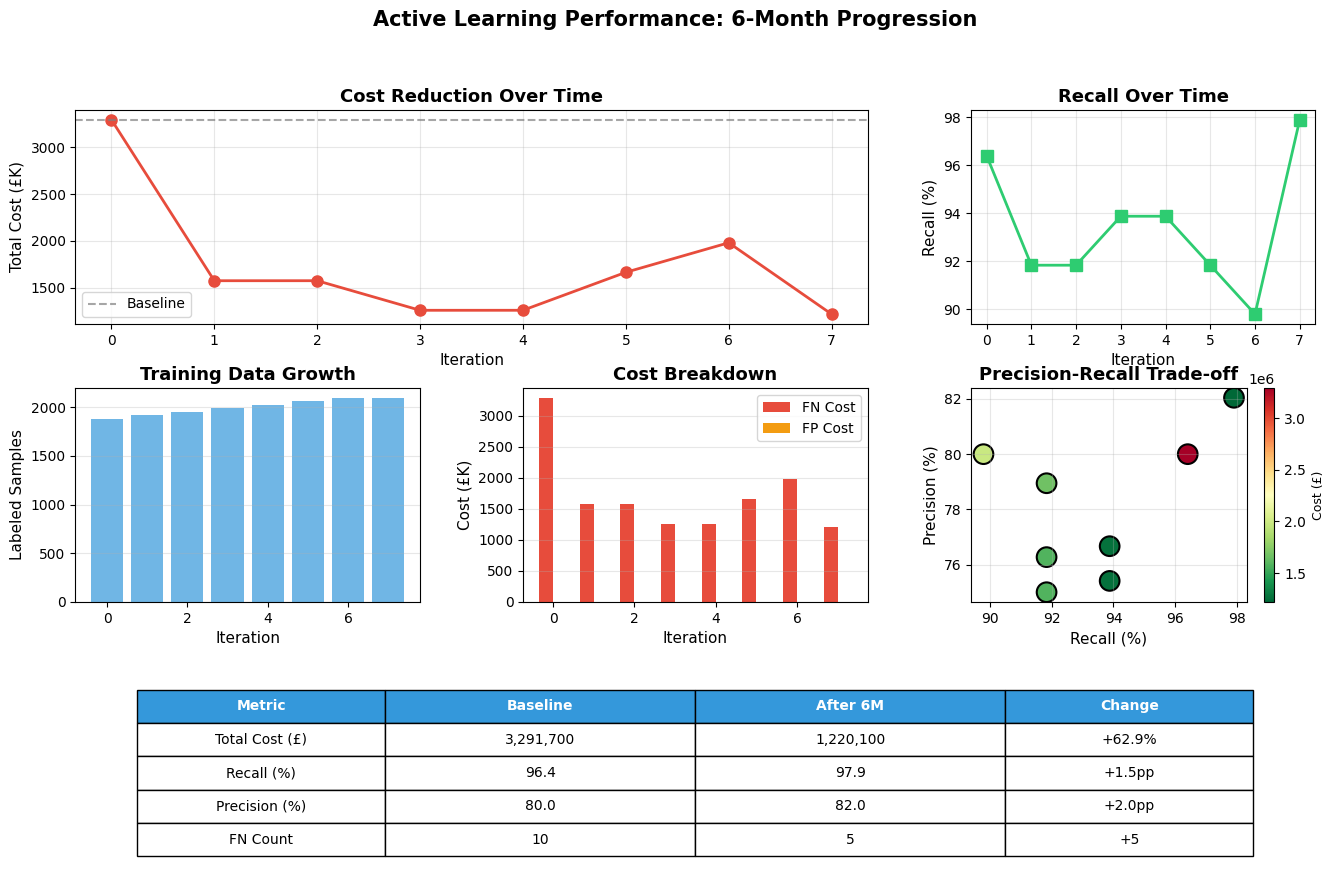


ACTIVE LEARNING WORKFLOW COMPLETE


In [ ]:
# Load universe data
print("Loading universe data...")
df_universe = df.copy()

print(f"Universe size: {len(df_universe)} records")
print(f"Fraud rate: {df_universe['fraud_label'].mean()*100:.2f}%")

# Run Active Learning workflow
al_model, history = run_active_learning_workflow(
    df_universe,
    n_test=5000,
    n_months=6,
    monthly_customers=500
)

print("\n" + "="*100)
print("ACTIVE LEARNING WORKFLOW COMPLETE")
print("="*100)